In [2]:
#importing required library
import requests
import pandas as pd
import re
import plotly.express as px



In [3]:
# API Config Stuffs
def get_attr_value(attrs, name):
    for attr in attrs:
        if attr.get("name") == name:
            return attr.get("value")
    return None


In [14]:
def fetch_data(page):
    url = "https://jiji.ng/api_web/v1/listing"

    params = {
        "slug": "houses-apartments-for-sale",
        "page": page,
        "webp": True
    }

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    try:
        response = requests.get(
            url,
            headers=headers,
            params=params
        )

        data = response.json()

    except requests.RequestException:
        print(f"[Page {page}] Request Error")
        return []

    except ValueError:
        print(f"[Page {page}] Decode Error")
        return []

    adverts_list = data.get("adverts_list", [])
    adverts = adverts_list.get("adverts", [])

    if not isinstance(adverts, list):
        print(f"An error occurred. Expected list but got {type(adverts)}")
        return []

    return adverts

In [4]:
# ads = fetch_data(1)
# print(ads)

In [16]:
def main():

    all_ads = []

    for page in range(1, 101):

        ads = fetch_data(page)

        print(f"Page {page}. {len(ads)} ads found")

        for ad in ads:

            if isinstance(ad, dict):

                attrs = ad.get("attrs", [])

                title = ad.get("title", "")

                region = ad.get("region", "")
                region_name = ad.get("region_name", "")
                region_parent_name = ad.get("region_parent_name", "")

                price = ad.get("price_title", "")

                property_size = get_attr_value(
                    attrs,
                    "Property size"
                )

                bedrooms = get_attr_value(
                    attrs,
                    "Bedrooms"
                )

                bathrooms = get_attr_value(
                    attrs,
                    "Bathrooms"
                )

                furnishing = get_attr_value(
                    attrs,
                    "Furnishing"
                )

                is_boost = ad.get("is_boost", "")

                if price:

                    all_ads.append({
                        "title": title,
                        "region": region,
                        "region_name": region_name,
                        "region_parent_name": region_parent_name,
                        "price": price,
                        "property_size": property_size,
                        "bedrooms": bedrooms,
                        "bathrooms": bathrooms,
                        "furnishing": furnishing,
                        "is_boost": is_boost
                    })

    if all_ads:

        df = pd.DataFrame(all_ads)

        df.to_csv(
            "jiji_housing_raw.csv",
            index=False
        )

        print("Successfully extracted data from Jiji")
        print(f"Total listings: {len(df)}")

    else:

        print("Nothing extracted")


main()

Page 1. 20 ads found
Page 2. 20 ads found
Page 3. 20 ads found
Page 4. 20 ads found
Page 5. 20 ads found
Page 6. 20 ads found
Page 7. 20 ads found
Page 8. 20 ads found
Page 9. 20 ads found
Page 10. 20 ads found
Page 11. 20 ads found
Page 12. 20 ads found
Page 13. 20 ads found
Page 14. 20 ads found
Page 15. 20 ads found
Page 16. 20 ads found
Page 17. 20 ads found
Page 18. 20 ads found
Page 19. 20 ads found
Page 20. 20 ads found
Page 21. 20 ads found
Page 22. 20 ads found
Page 23. 20 ads found
Page 24. 20 ads found
Page 25. 20 ads found
Page 26. 20 ads found
Page 27. 20 ads found
Page 28. 20 ads found
Page 29. 20 ads found
Page 30. 20 ads found
Page 31. 20 ads found
Page 32. 20 ads found
Page 33. 20 ads found
Page 34. 20 ads found
Page 35. 20 ads found
Page 36. 20 ads found
Page 37. 20 ads found
Page 38. 20 ads found
Page 39. 20 ads found
Page 40. 20 ads found
Page 41. 20 ads found
Page 42. 20 ads found
Page 43. 20 ads found
Page 44. 20 ads found
Page 45. 20 ads found
Page 46. 20 ads fou

# Working on the dataset

In [5]:
# Loading data in to the workspace 
df = pd.read_csv("jiji_housing_raw.csv")
df.head()

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,"₦ 600,000,000",800.0,4,5,Furnished,vip_gold
1,3bdrm Block of Flats in Ado-Odo/Ota for sale,"Ogun State, Ado-Odo/Ota",Ado-Odo/Ota,Ogun State,"₦ 30,000,000",1000.0,3,3,Unfurnished,False
2,3bdrm Bungalow in Ikpoba-Okha for sale,"Edo State, Ikpoba-Okha",Ikpoba-Okha,Edo State,"₦ 9,000,000",464.0,3,2,Unfurnished,False
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,"₦ 120,000,000",450.0,2,2,Unfurnished,diamond
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,"₦ 150,000,000",150.0,3,3,Unfurnished,False


In [6]:
df.isnull().sum()

title                 0
region                0
region_name           0
region_parent_name    7
price                 0
property_size         3
bedrooms              0
bathrooms             0
furnishing            0
is_boost              0
dtype: int64

In [7]:
df['property_size'] = pd.to_numeric(df['property_size'], errors='coerce')
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

In [8]:
df.isnull().sum()

title                 0
region                0
region_name           0
region_parent_name    7
price                 0
property_size         3
bedrooms              0
bathrooms             0
furnishing            0
is_boost              0
dtype: int64

In [9]:
# drop the nan values
df = df.dropna()
df.isnull().sum()

title                 0
region                0
region_name           0
region_parent_name    0
price                 0
property_size         0
bedrooms              0
bathrooms             0
furnishing            0
is_boost              0
dtype: int64

# Price Cleaning & Outlier Handling

In [10]:
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    # Remove '₦', commas, and spaces, then convert to float
    cleaned = re.sub(r'[^\d.]', '', str(price_str))
    return float(cleaned) if cleaned else np.nan

df['price'] = df['price'].apply(clean_price)

df['price']

0       600000000.0
1        30000000.0
2         9000000.0
3       120000000.0
4       150000000.0
           ...     
1995     70000000.0
1996    460000000.0
1997    350000000.0
1998    470000000.0
1999    230000000.0
Name: price, Length: 1990, dtype: float64

In [11]:
df.head()

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,vip_gold
1,3bdrm Block of Flats in Ado-Odo/Ota for sale,"Ogun State, Ado-Odo/Ota",Ado-Odo/Ota,Ogun State,30000000.0,1000.0,3,3,Unfurnished,False
2,3bdrm Bungalow in Ikpoba-Okha for sale,"Edo State, Ikpoba-Okha",Ikpoba-Okha,Edo State,9000000.0,464.0,3,2,Unfurnished,False
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,diamond
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,False


In [13]:
upper_limit = df['price'].quantile(0.95)
lower_limit = df['price'].quantile(0.05) # 

print(f"Removing prices below ₦{lower_limit:,.0f} and above ₦{upper_limit:,.0f}")


Removing prices below ₦70,000,000 and above ₦2,277,500,000


In [14]:
df_clean = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)].copy()

print(f"Rows before outlier removal: {len(df)}")
print(f"Rows after outlier removal: {len(df_clean)}")
print(f"New Mean Price: ₦{df_clean['price'].mean():,.0f}")
print(f"New Median Price: ₦{df_clean['price'].median():,.0f}")


Rows before outlier removal: 1990
Rows after outlier removal: 1792
New Mean Price: ₦459,309,691
New Median Price: ₦317,500,000


In [16]:
df_clean

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,vip_gold
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,diamond
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,False
5,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,diamond
7,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,vip
...,...,...,...,...,...,...,...,...,...,...
1995,2bdrm Block of Flats in Idu Industrial for sale,"Abuja (FCT), Idu Industrial",Idu Industrial,Abuja (FCT),70000000.0,200.0,2,2,Unfurnished,diamond
1996,5bdrm Duplex in Oshimili North for sale,"Delta State, Oshimili North",Oshimili North,Delta State,460000000.0,450.0,5,5,Semi-Furnished,enterprise
1997,"3bdrm Apartment in Elegushi, Ikate for sale","Lekki, Ikate",Ikate,Lekki,350000000.0,860.0,3,3,Unfurnished,enterprise
1998,5bdrm Duplex in Lekki for sale,"Lagos State, Lekki",Lekki,Lagos State,470000000.0,300.0,5,5,Semi-Furnished,diamond


In [17]:
# Standardize Region Names
df_clean['region_parent_name'] = df_clean['region_parent_name'].astype(str).str.strip().str.title()
df_clean['region_name'] = df_clean['region_name'].astype(str).str.strip().str.title()

In [18]:
df_clean

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,vip_gold
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,diamond
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,False
5,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,diamond
7,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,vip
...,...,...,...,...,...,...,...,...,...,...
1995,2bdrm Block of Flats in Idu Industrial for sale,"Abuja (FCT), Idu Industrial",Idu Industrial,Abuja (Fct),70000000.0,200.0,2,2,Unfurnished,diamond
1996,5bdrm Duplex in Oshimili North for sale,"Delta State, Oshimili North",Oshimili North,Delta State,460000000.0,450.0,5,5,Semi-Furnished,enterprise
1997,"3bdrm Apartment in Elegushi, Ikate for sale","Lekki, Ikate",Ikate,Lekki,350000000.0,860.0,3,3,Unfurnished,enterprise
1998,5bdrm Duplex in Lekki for sale,"Lagos State, Lekki",Lekki,Lagos State,470000000.0,300.0,5,5,Semi-Furnished,diamond


In [19]:
furnishing_map = {
    'furnished': 'Furnished',
    'semi-furnished': 'Semi-Furnished',
    'unfurnished': 'Unfurnished',
    'unknown': 'Unknown',
    'nan': 'Unknown'
}
df_clean['furnishing'] = df_clean['furnishing'].astype(str).str.strip().str.lower().map(furnishing_map).fillna('Unknown')


In [20]:
# Standardize Boost Status
boost_keywords = ['vip', 'vip_gold', 'diamond', 'enterprise', 'premium', 'basic', 'true']
df_clean['is_boost'] = df_clean['is_boost'].astype(str).str.lower().apply(
    lambda x: 'Boosted' if any(keyword in x for keyword in boost_keywords) else 'Regular'
)


In [21]:
df_clean.head()

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,Boosted
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,Boosted
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,Regular
5,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,Boosted
7,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,Boosted


In [22]:
# Ensure integer types for bedrooms/bathrooms
df_clean['bedrooms'] = df_clean['bedrooms'].astype(int)
df_clean['bathrooms'] = df_clean['bathrooms'].astype(int)


In [23]:
df_clean.dtypes

title                     str
region                    str
region_name               str
region_parent_name        str
price                 float64
property_size         float64
bedrooms                int64
bathrooms               int64
furnishing                str
is_boost                  str
dtype: object

In [24]:
df_clean.head()

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,Boosted
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,Boosted
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,Regular
5,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,Boosted
7,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,Boosted


In [25]:
# Remove Duplicates
df_clean = df_clean.drop_duplicates(subset=['title', 'price', 'region_name']).reset_index(drop=True)


In [26]:
df_clean.head()

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,Boosted
1,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,Boosted
2,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,Regular
3,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,Boosted
4,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,Boosted


In [27]:
df_clean

,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,Boosted
1,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,Boosted
2,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,Regular
3,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,Boosted
4,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,Boosted
...,...,...,...,...,...,...,...,...,...,...
1624,4bdrm Duplex in Festac for sale,"Amuwo-Odofin, Festac",Festac,Amuwo-Odofin,250000000.0,600.0,4,4,Unfurnished,Boosted
1625,2bdrm Block of Flats in Idu Industrial for sale,"Abuja (FCT), Idu Industrial",Idu Industrial,Abuja (Fct),70000000.0,200.0,2,2,Unfurnished,Boosted
1626,5bdrm Duplex in Oshimili North for sale,"Delta State, Oshimili North",Oshimili North,Delta State,460000000.0,450.0,5,5,Semi-Furnished,Boosted
1627,"3bdrm Apartment in Elegushi, Ikate for sale","Lekki, Ikate",Ikate,Lekki,350000000.0,860.0,3,3,Unfurnished,Boosted


In [28]:
df_clean = df_clean.rename(columns={
    "title": "Title",
    "region": "Region",
    "region_name":"Region Name",
    "region_parent_name": "Region Parent Name",
    "price": "Price",
    "property_size": "Property Size",
    "bedrooms":"Bedrooms",
    "bathrooms":"Bathrooms",
    "furnishing": "Furnishing",
    "is_boost": "Is Boosted"
    
    
})

df_clean.head()

,Title,Region,Region Name,Region Parent Name,Price,Property Size,Bedrooms,Bathrooms,Furnishing,Is Boosted
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,Boosted
1,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,Boosted
2,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,Regular
3,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,Boosted
4,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,Boosted


In [29]:
df_clean.to_csv('jiji_housing_cleaned.csv', index=False)
print("Data cleaned successfully and saved to jiji_housing_cleaned.csv")

df = pd.read_csv("jiji_housing_cleaned.csv")
df.head()

Data cleaned successfully and saved to jiji_housing_cleaned.csv


,Title,Region,Region Name,Region Parent Name,Price,Property Size,Bedrooms,Bathrooms,Furnishing,Is Boosted
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,Boosted
1,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,Boosted
2,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,Regular
3,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,Boosted
4,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,Boosted


In [30]:
# Price Analysis
avg_price = df['Price'].mean()
state_avg_price = df.groupby('Region Parent Name')['Price'].mean()
highest_priced_state = state_avg_price.idxmax()
lowest_priced_state = state_avg_price.idxmin()
print(f"1. Average house price in Nigeria: ₦{avg_price:,.2f}")
print(f"   Highest mean price: {highest_priced_state} (₦{state_avg_price.max():,.2f})")
print(f"   Lowest mean price: {lowest_priced_state} (₦{state_avg_price.min():,.2f})")

1. Average house price in Nigeria: ₦451,848,352.08
   Highest mean price: Kwara State (₦1,300,000,000.00)
   Lowest mean price: Ikorodu (₦72,500,000.00)


In [31]:
#  Property Size & Features
print(f"\n2. Median Property Size: {df['Property Size'].median()} sqm")
corr_size_price = df['Property Size'].corr(df['Price'])
corr_bed_price = df['Bedrooms'].corr(df['Price'])
print(f"   Correlation (Size vs Price): {corr_size_price:.2f}")
print(f"   Correlation (Bedrooms vs Price): {corr_bed_price:.2f}")


2. Median Property Size: 500.0 sqm
   Correlation (Size vs Price): 0.30
   Correlation (Bedrooms vs Price): 0.20


In [32]:
#  Regional Trends
top_regions = df['Region Parent Name'].value_counts().head(3)
print(f"\n3. Top 3 Regions by Listing Volume:\n{top_regions}")



3. Top 3 Regions by Listing Volume:
Region Parent Name
Lekki          344
Abuja (Fct)    289
Lagos State    253
Name: count, dtype: int64


In [33]:
# 4. Furnishing Analysis
furnishing_avg = df.groupby('Furnishing')['Price'].mean().sort_values(ascending=False)
print(f"\n4. Average Price by Furnishing:\n{furnishing_avg}")

# 5. Listing Type
boost_avg = df.groupby('Is Boosted')['Price'].mean()
print(f"\n5. Average Price by Listing Type:\n{boost_avg}")



4. Average Price by Furnishing:
Furnishing
Semi-Furnished    5.057336e+08
Unfurnished       4.150418e+08
Furnished         3.815387e+08
Name: Price, dtype: float64

5. Average Price by Listing Type:
Is Boosted
Boosted    4.534833e+08
Regular    2.113636e+08
Name: Price, dtype: float64


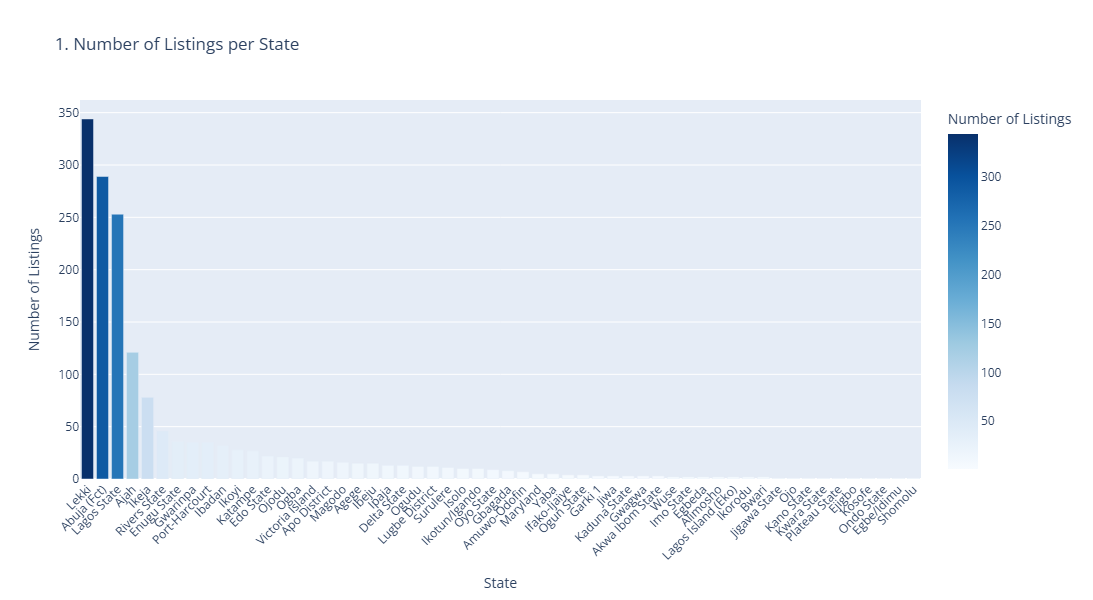

In [34]:
# ==========================================
# 1. Bar Chart: Number of listings per state
# ==========================================
state_counts = df['Region Parent Name'].value_counts().reset_index()
state_counts.columns = ['State', 'Number_of_Listings']

fig1 = px.bar(state_counts, 
              x='State', 
              y='Number_of_Listings',
              title='1. Number of Listings per State',
              labels={'State': 'State', 'Number_of_Listings': 'Number of Listings'},
              color='Number_of_Listings',
              color_continuous_scale='Blues')
fig1.update_layout(xaxis_tickangle=-45, height=600)
fig1.show()


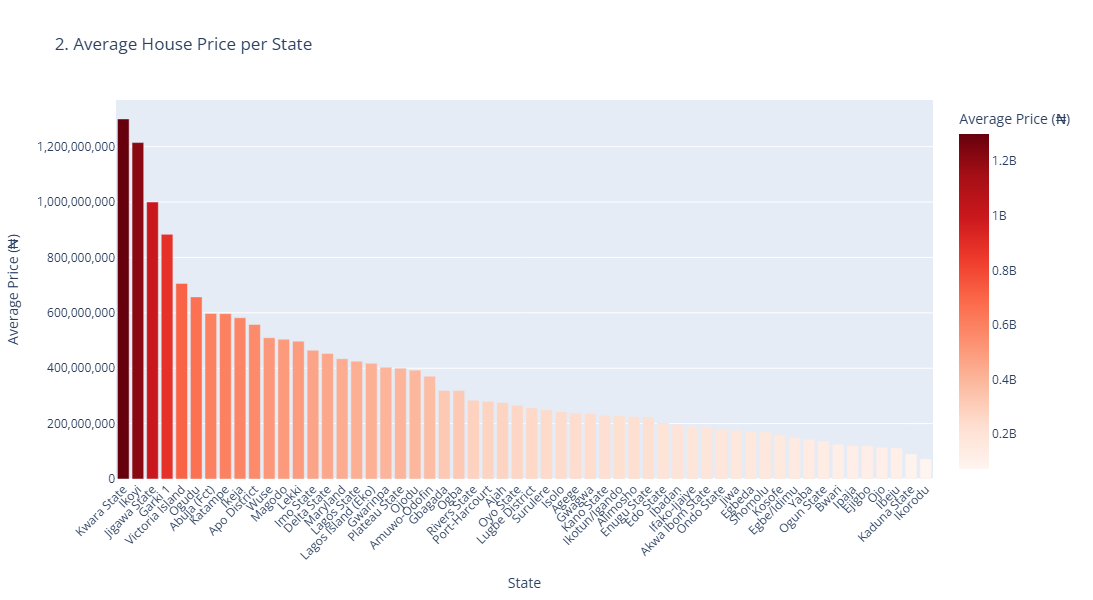

In [35]:
# 2. Bar Chart: Average price per state
# ==========================================
state_avg_price = df.groupby('Region Parent Name')['Price'].mean().reset_index()
state_avg_price.columns = ['State', 'Average_Price']
state_avg_price = state_avg_price.sort_values(by='Average_Price', ascending=False)

fig2 = px.bar(state_avg_price, 
              x='State', 
              y='Average_Price',
              title='2. Average House Price per State',
              labels={'State': 'State', 'Average_Price': 'Average Price (₦)'},
              color='Average_Price',
              color_continuous_scale='Reds')
fig2.update_layout(xaxis_tickangle=-45, height=600)
fig2.update_yaxes(tickformat=',.0f')
fig2.show()

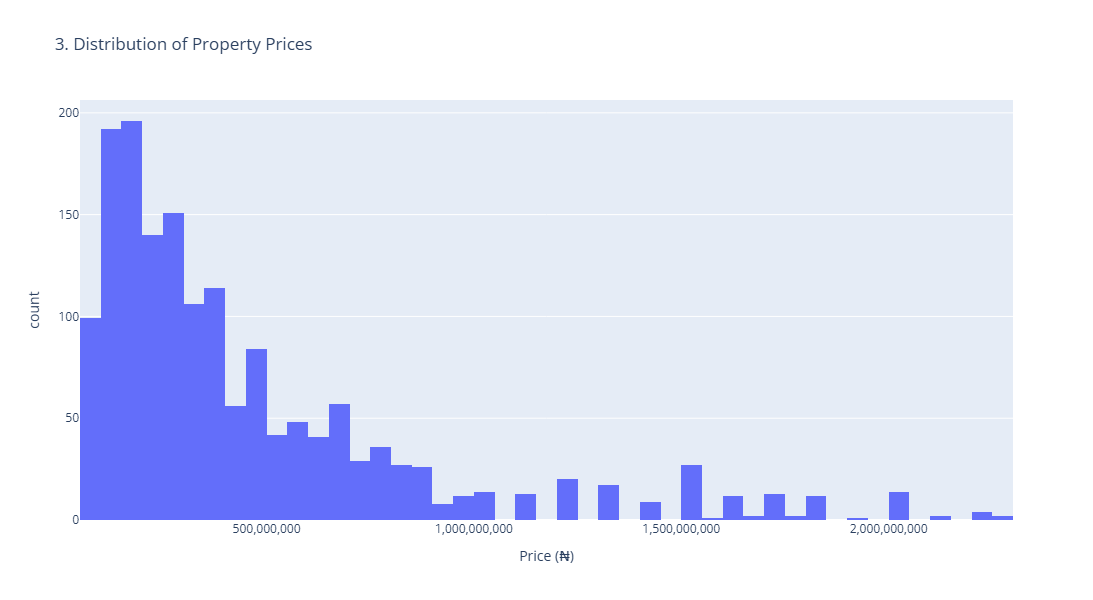

In [36]:
# ==========================================
# 3. Histogram: Distribution of property prices
# ==========================================
fig3 = px.histogram(df, 
                    x='Price',
                    title='3. Distribution of Property Prices',
                    labels={'Price': 'Price (₦)'},
                    nbins=50,
                    color_discrete_sequence=['#636EFA'])
fig3.update_layout(height=600)
fig3.update_xaxes(tickformat=',.0f')
fig3.show()


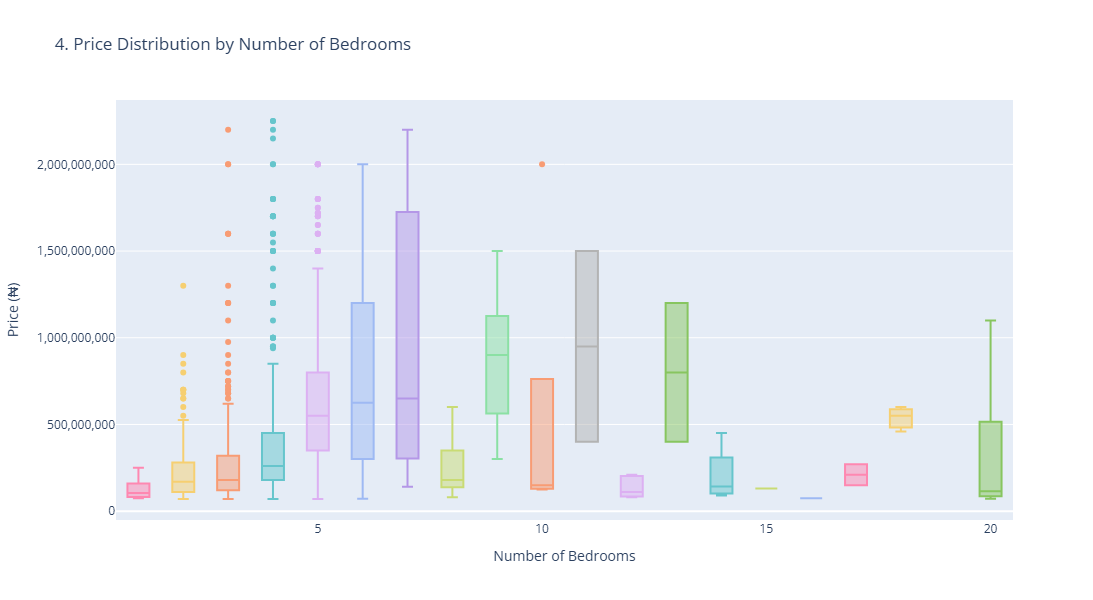

In [37]:
# ==========================================
# 4. Boxplot: Price by number of bedrooms
# ==========================================
fig4 = px.box(df, 
              x='Bedrooms', 
              y='Price',
              title='4. Price Distribution by Number of Bedrooms',
              labels={'Bedrooms': 'Number of Bedrooms', 'Price': 'Price (₦)'},
              color='Bedrooms',
              color_discrete_sequence=px.colors.qualitative.Pastel)
fig4.update_layout(height=600, showlegend=False)
fig4.update_yaxes(tickformat=',.0f')
fig4.show()

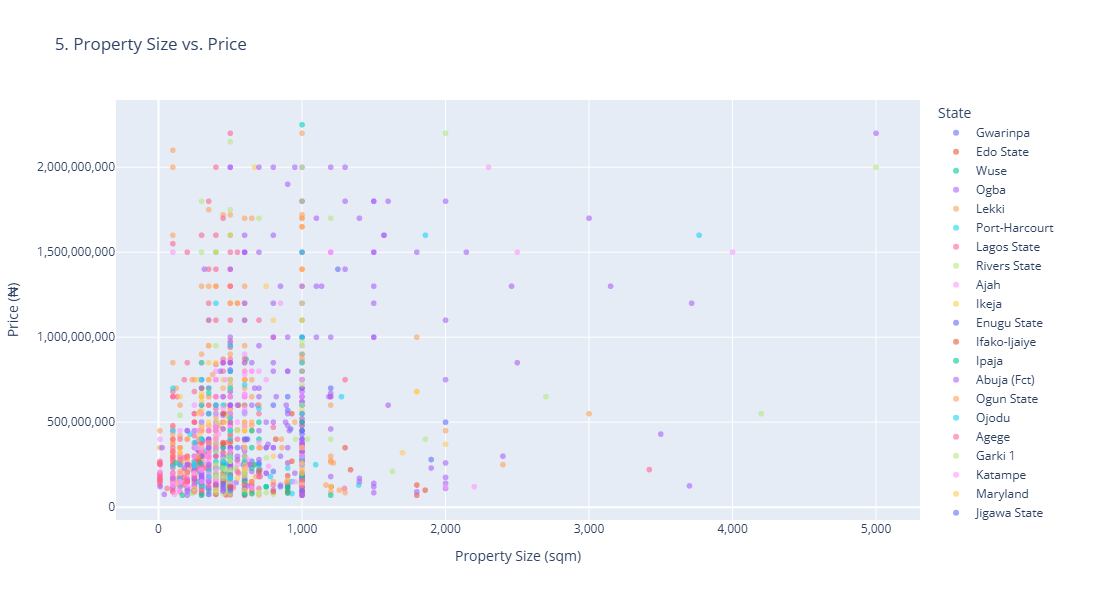

In [38]:
# ==========================================
# 5. Scatter Plot: Property size vs. price
# ==========================================
fig5 = px.scatter(df, 
                  x='Property Size', 
                  y='Price',
                  title='5. Property Size vs. Price',
                  labels={'Property Size': 'Property Size (sqm)', 'Price': 'Price (₦)'},
                  color='Region Parent Name',
                  opacity=0.6,
                  hover_data=['Title', 'Region Name', 'Bedrooms'])
fig5.update_layout(height=600, legend_title='State')
fig5.update_xaxes(tickformat=',.0f')
fig5.update_yaxes(tickformat=',.0f')
fig5.show()

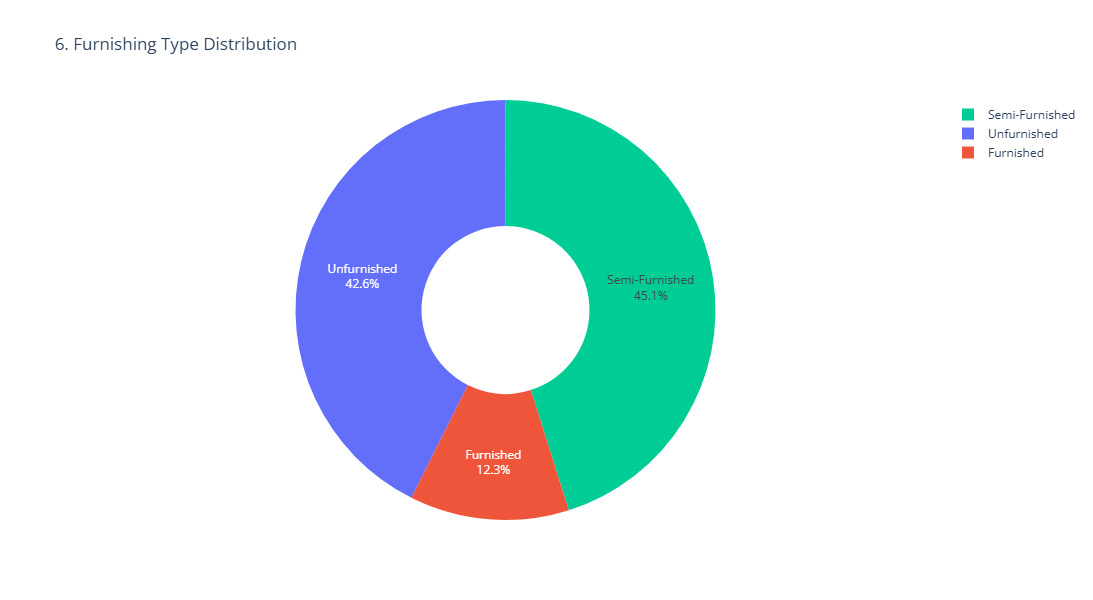

In [39]:
# ==========================================
# 6. Pie Chart: Furnishing type distribution
# ==========================================
furnishing_counts = df['Furnishing'].value_counts().reset_index()
furnishing_counts.columns = ['Furnishing_Type', 'Count']

fig6 = px.pie(furnishing_counts, 
              values='Count', 
              names='Furnishing_Type',
              title='6. Furnishing Type Distribution',
              hole=0.4,
              color='Furnishing_Type',
              color_discrete_map={
                  'Unfurnished': '#636EFA',
                  'Semi-Furnished': '#00CC96',
                  'Furnished': '#EF553B',
                  'Unknown': '#AB63FA'
              })
fig6.update_traces(textposition='inside', textinfo='percent+label')
fig6.update_layout(height=600)
fig6.show()

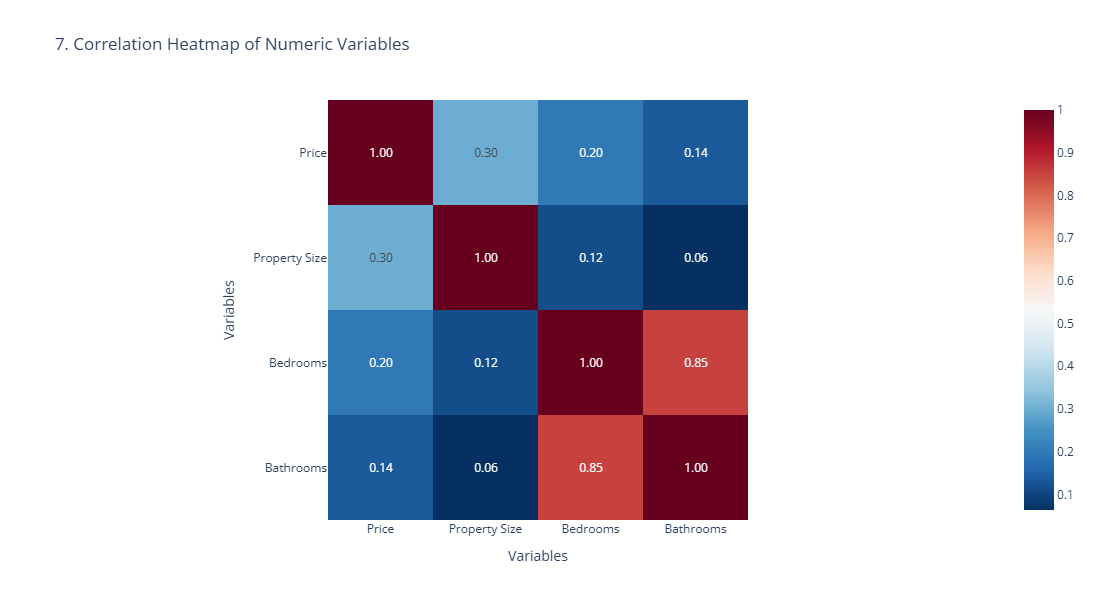

In [40]:
# ==========================================
# 7. Heatmap: Correlation of numeric variables
# ==========================================
# Select numeric columns
numeric_df = df[['Price', 'Property Size', 'Bedrooms', 'Bathrooms']].dropna()
corr_matrix = numeric_df.corr()

fig7 = px.imshow(corr_matrix,
                 text_auto='.2f',
                 color_continuous_scale='RdBu_r',
                 title='7. Correlation Heatmap of Numeric Variables',
                 labels={'x': 'Variables', 'y': 'Variables'})
fig7.update_layout(height=600)
fig7.show()

In [41]:
# Print correlation insights
print("\n=== CORRELATION INSIGHTS ===")
print(f"Price vs Property Size: {corr_matrix.loc['Price', 'Property Size']:.3f}")
print(f"Price vs Bedrooms: {corr_matrix.loc['Price', 'Bedrooms']:.3f}")
print(f"Price vs Bathrooms: {corr_matrix.loc['Price', 'Bathrooms']:.3f}")
print(f"Bedrooms vs Bathrooms: {corr_matrix.loc['Bedrooms', 'Bathrooms']:.3f}")


=== CORRELATION INSIGHTS ===
Price vs Property Size: 0.300
Price vs Bedrooms: 0.197
Price vs Bathrooms: 0.136
Bedrooms vs Bathrooms: 0.852


Here is a concise, well-structured Markdown summary of your findings, insights, and strategic recommendations.

---

# Real Estate Market Analysis: Key Insights & Recommendations

## Summary of Data Insights

* **Market Hubs & Pricing:** Market volume is heavily concentrated in **Lekki**, **Abuja (FCT)**, and **Lagos State**. Luxury hubs like **Wuse (Abuja)** and **Ikoyi (Lagos)** lead valuation with average listing prices exceeding **₦3.9B–₦4B+**.
* **Price Distribution:** Heavily right-skewed. The median price is **₦320M**, while ultra-luxury listings push the overall mean to **₦705M**. Most listings cluster between **₦170M and ₦650M**.
* **Key Valuation Drivers:**
* **Capacity & Size:** Property capacity directly drives base price (1-bedroom median: **₦86M** vs. 5-bedroom median: **₦580M**). Square meterage shows a moderate correlation with price ($r = 0.43$).
* **Location vs. Size:** Location and finishing often outweigh raw size; a smaller property in Ikoyi outprices a larger mansion in an outer region.
* **Furnishing:** Semi-furnished (**45%**) and unfurnished (**44%**) dominate volume, but fully furnished homes command the highest average price (**₦954M** vs. **₦562M** unfurnished).
* **Promoted Listings:** Boosted (VIP/Enterprise) listings average **₦712M** vs. **₦118M** for standard listings, indicating sellers heavily invest in visibility for high-value properties.



---

##  Business Recommendations

* **Top Revenue Focus:** Prioritize inventory acquisition and marketing in **Lagos (Lekki, Ikoyi, Ikeja GRA)** and **Abuja (Wuse, Maitama)**. The best-performing assets are **4–5 bedroom semi-furnished/furnished duplexes** in secure gated estates.
* **Low-Performing Region Strategy:** In price-sensitive markets (e.g., Ekiti, Kwara, Plateau), drive adoption by promoting **affordable housing packages, flexible payment/mortgage plans**, and infrastructure-adjacent listings.
* **Seller Optimization:** Encourage sellers of mid-to-high-tier properties to leverage **boosted/VIP listings**, professional photography, and clear highlights of security features and furnishing status to maximize return.